In [31]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Inversion d'une image

In [32]:

# Load the image 
image_path = 'rose_1024.tif'  
image = Image.open(image_path)


In [33]:

# Convert the image to a NumPy array
image_array = np.array(image)
image_array

array([[21, 17, 15, ..., 23, 23, 23],
       [20, 19, 17, ..., 23, 23, 23],
       [17, 17, 20, ..., 24, 23, 23],
       ...,
       [ 7,  7,  7, ..., 21, 21, 21],
       [10, 10, 10, ..., 17, 17, 17],
       [10, 10, 10, ..., 15, 15, 15]], dtype=uint8)

In [34]:

# Create the negative image by inverting colors
negative_image_array = 255 - image_array
negative_image_array

array([[234, 238, 240, ..., 232, 232, 232],
       [235, 236, 238, ..., 232, 232, 232],
       [238, 238, 235, ..., 231, 232, 232],
       ...,
       [248, 248, 248, ..., 234, 234, 234],
       [245, 245, 245, ..., 238, 238, 238],
       [245, 245, 245, ..., 240, 240, 240]], dtype=uint8)

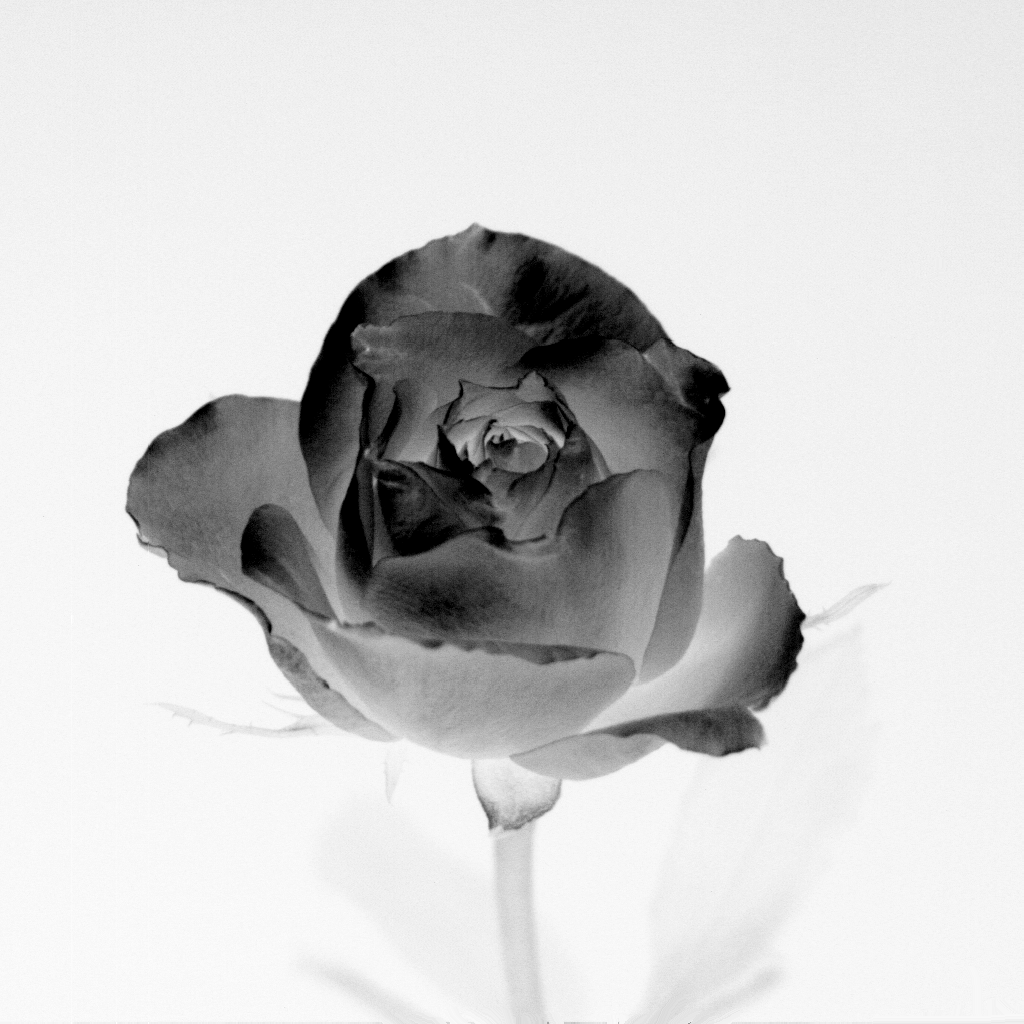

In [35]:
# Convert the inverted array back to an image
negative_image = Image.fromarray(negative_image_array)
negative_image

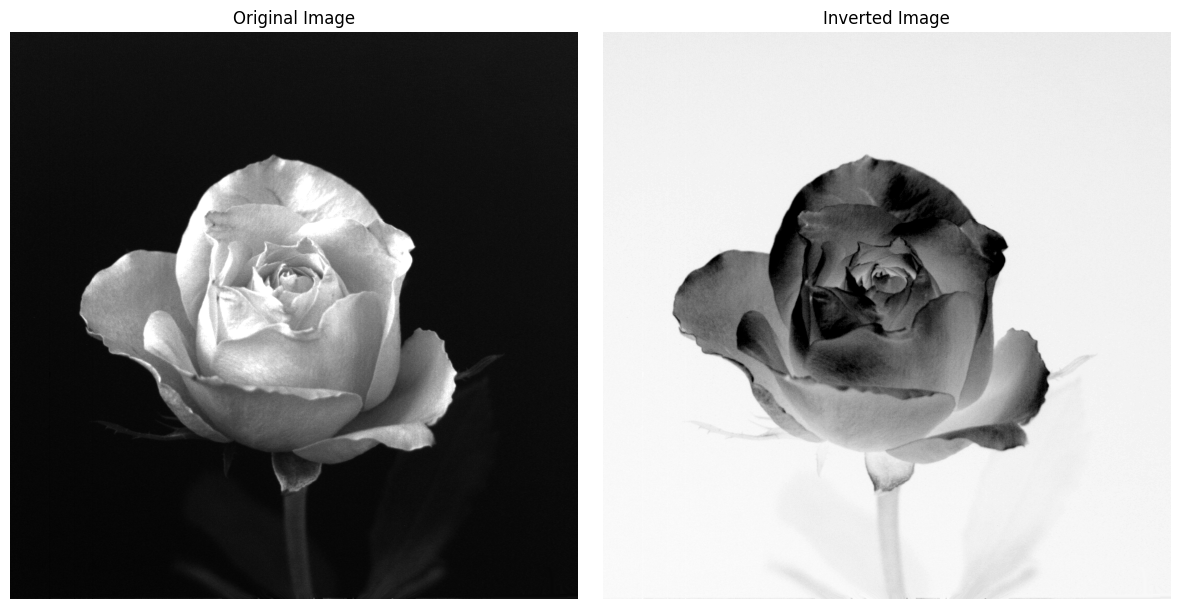

In [36]:

# Display the original and inverted images side by side
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_array, cmap='gray' if image.mode == 'L' else None)
plt.axis('off')

# Inverted image
plt.subplot(1, 2, 2)
plt.title("Inverted Image")
plt.imshow(negative_image_array, cmap='gray' if image.mode == 'L' else None)
plt.axis('off')

plt.tight_layout()
plt.show()


# Addition de deux images

In [37]:
import cv2

In [38]:
# Load the two images
image1_path = 'toADD.bmp'       
image2_path = 'rose_1024.tif'

In [39]:
# Read the images using cv2
image1 = cv2.imread(image1_path)  
image2 = cv2.imread(image2_path)  

In [40]:
# Ensure  image is resized 
height, width = image1.shape[:2]  
image2_resized = cv2.resize(image2, (width, height))  

In [41]:
# Initialize an empty array 
added_images = np.zeros_like(image1)

# Perform pixel-by-pixel addition with an explicit 'if' condition
for i in range(height):
    for j in range(width):
        pixel_sum = image1[i, j] + image2_resized[i, j]
        if pixel_sum.all() > 255:
            added_images[i, j] = 255 
        else:
            added_images[i, j] = pixel_sum


In [42]:
added_images

array([[[ 21,  21,  21],
        [ 17,  17,  17],
        [ 15,  15,  15],
        ...,
        [ 23,  23,  23],
        [ 23,  23,  23],
        [ 23,  23,  23]],

       [[ 20,  20,  20],
        [ 19,  19,  19],
        [ 17,  17,  17],
        ...,
        [ 23,  23,  23],
        [ 23,  23,  23],
        [ 23,  23,  23]],

       [[ 17,  17,  17],
        [ 17,  17,  17],
        [ 20,  20,  20],
        ...,
        [ 24,  24,  24],
        [ 23,  23,  23],
        [ 23,  23,  23]],

       ...,

       [[167, 167, 167],
        [167, 167, 167],
        [167, 167, 167],
        ...,
        [180, 180, 180],
        [180, 180, 180],
        [180, 180, 180]],

       [[170, 170, 170],
        [170, 170, 170],
        [170, 170, 170],
        ...,
        [177, 177, 177],
        [177, 177, 177],
        [177, 177, 177]],

       [[170, 170, 170],
        [170, 170, 170],
        [170, 170, 170],
        ...,
        [175, 175, 175],
        [175, 175, 175],
        [175, 175, 175]]

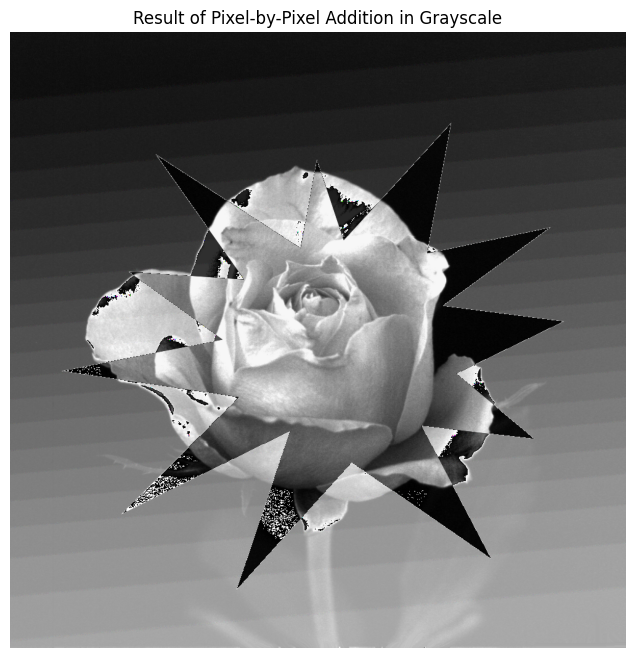

In [43]:
# Display the resulting image
plt.figure(figsize=(8, 8))
plt.title("Result of Pixel-by-Pixel Addition in Grayscale")
plt.imshow(added_images, cmap='gray')  # Show the result in grayscale
plt.axis('off')
plt.show()

* Perform addition with cv2.add() function

In [44]:
# Perform addition
added_image_comp = cv2.add(image1, image2_resized)  # Ensures values are clamped to [0, 255]

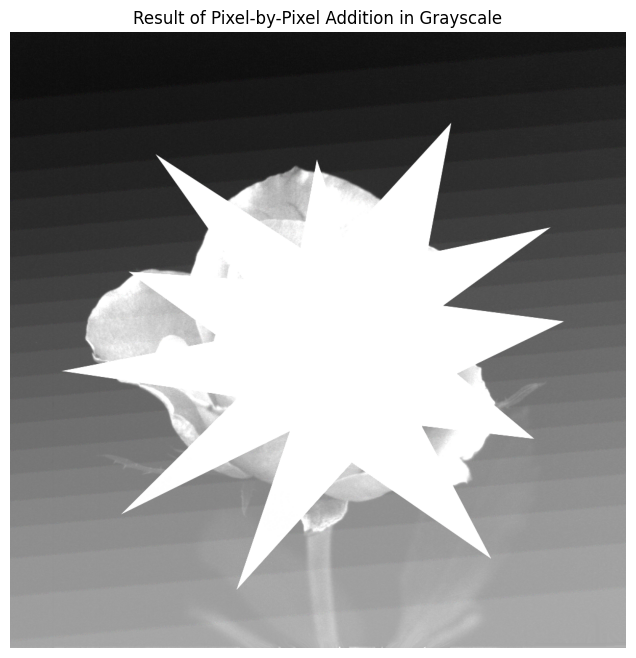

In [45]:
# Display the resulting image
plt.figure(figsize=(8, 8))
plt.title("Result of Pixel-by-Pixel Addition in Grayscale")
plt.imshow(added_image_comp, cmap='gray')  # Show the result in grayscale
plt.axis('off')
plt.show()

# Rotation d’une image

In [46]:
# Load the image
rose_path = 'rose_1024.tif'
rose = cv2.imread(rose_path)

# Get the image dimensions
height, width = rose.shape[:2]

# Define the center of the image for rotation (center point)
center = (width // 2, height // 2)

# Create the rotation matrix for a 45 degree rotation
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1)  

# Perform the rotation using warpAffine
rotated_image = cv2.warpAffine(rose, rotation_matrix, (width, height))

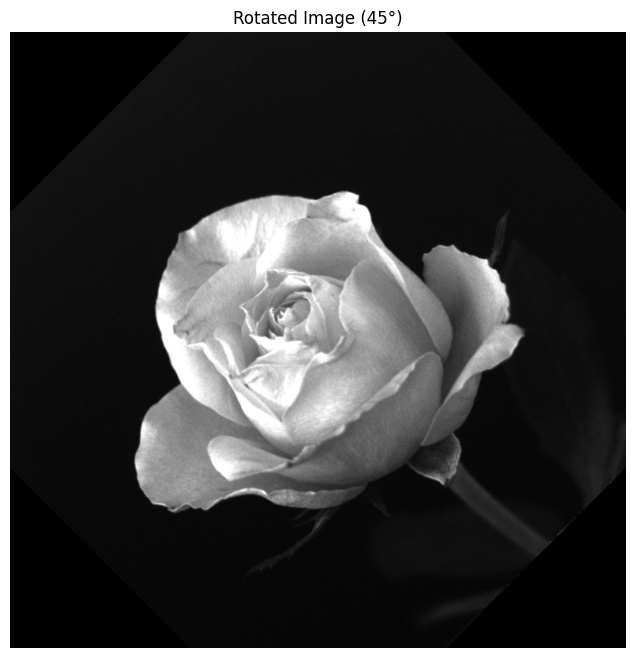

In [47]:

# Display the resulting image
plt.figure(figsize=(8, 8))
plt.title("Rotated Image (45°)")
plt.imshow(rotated_image, cmap='gray')  # Convert BGR to RGB for displaying in matplotlib
plt.axis('off')  # Hide axis
plt.show()
